# ENGR 1451/2451 — Weekly Assignment 2
**10 points**

This assignment applies the descriptive-statistics and visual-exploration methods introduced in the W02A lab notebooks: center and spread, quartiles and outliers, histograms and boxplots, grouped summaries, and the importance of pairing numerical summaries with visualizations.


 **Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.


## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.


## Setup

Put `iris.csv` in a folder named `data` next to this notebook so that the path below works.


In [64]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

iris = pd.read_csv(Path("./data/iris.csv"))
iris.head()


,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## LE2-1. Shifting and scaling data (2 pts)

Consider the following measurements:

\[
x = [4,\ 6,\ 8,\ 10,\ 12].
\]

Create two transformed versions:

- **shifted:** \(x + 7\)
- **scaled:** \(3x\)

### A. Predict first (1 pt)

Without calculating, predict what happens to the **mean**, **median**, **sample standard deviation**, and **IQR** after each transformation.

Complete the table in words such as *increases by 7*, *unchanged*, or *multiplied by 3*.

| Statistic | After adding 7 | After multiplying by 3 |
|---|---|---|
| Mean | | |
| Median | | |
| Sample standard deviation | | |
| IQR | | |


**Answer:**

| Statistic | After adding 7 | After multiplying by 3 |
|---|---|---|
| Mean | Mean value will move by 7 of the original x | Mean value will move by 3 times of the original x |
| Median | Median will move by 7 like mean | Median will move 3 times similar to mean |
| Sample standard deviation | SD will stay the same like original x | SD will increase 3 times compered to x |
| IQR | IQR will stay the same like original x | IQR will increase 3 times |


### B. Verify with Python (1.5 pts)

Create a small summary table for the original, shifted, and scaled data containing:

- mean;
- median;
- sample standard deviation; and
- IQR.

Then state whether the results agree with your predictions.



In [65]:
x = pd.Series([4, 6, 8, 10, 12], name="original")
shifted = x + 7
scaled = 3 * x

data = {
    "name":    ["original", "shifted", "scaled"],
    "mean":    [x.mean(), shifted.mean(), scaled.mean()],
    "median":  [x.median(), shifted.median(), scaled.median()],
    "std":     [x.std(), shifted.std(), scaled.std()],
    "IQR":     [x.quantile(0.75) - x.quantile(0.25), shifted.quantile(0.75) - shifted.quantile(0.25), scaled.quantile(0.75) - scaled.quantile(0.25)]
}

df = pd.DataFrame(data)

df


,name,mean,median,std,IQR
0,original,8.0,8.0,3.162278,4.0
1,shifted,15.0,15.0,3.162278,4.0
2,scaled,24.0,24.0,9.486833,12.0


**Answer:**

The code confimrs the results with the Part A.


## LE2-2. Quartiles, IQR, and outliers (2 pts)

Use the Iris variable `sepal.width`.

1. Calculate \(Q_1\), the median, and \(Q_3\).
2. Calculate the IQR.
3. Calculate the lower and upper Tukey fences:
   \[
   Q_1 - 1.5\,\mathrm{IQR}
   \qquad\text{and}\qquad
   Q_3 + 1.5\,\mathrm{IQR}.
   \]
4. Use Python to identify every Iris observation whose `sepal.width` falls outside these fences.
5. Report how many observations are flagged and state whether they are low outliers, high outliers, or both.


In [66]:
sepal_width = iris["sepal.width"]


q1 = sepal_width.quantile(0.25)
q3 = sepal_width.quantile(0.75)
median = sepal_width.median()

iqr = q3 - q1

lower_fence = q1 - 1.5 * iqr
higher_fence = q3 + 1.5 * iqr

outliers_lower = sepal_width[(sepal_width < lower_fence)].count()
outliers_higher = sepal_width[(sepal_width > higher_fence)].count()

print(f"""
1. Q1 = {q1}, median = {median}, Q3 = {q3} \n
2. IQR = {iqr} \n
3. Lower fence = {lower_fence},  Higher fence = {higher_fence}\n
4. low outliers = {outliers_lower}, higher outliers = {outliers_higher}\n""")


1. Q1 = 2.8, median = 3.0, Q3 = 3.3 

2. IQR = 0.5 

3. Lower fence = 2.05,  Higher fence = 4.05

4. low outliers = 1, higher outliers = 3



**Answer:**
The report says that there is 1 lower outlier nad 3 higher outliers.

## LE2-3. Visualizing a distribution and comparing groups (4 pts)

Use `sepal.length` for all parts below.

### A. Histograms and bin choice (1.5 pts)

Create two histograms of the **same** `sepal.length` data:
- one using **6 bins**;
- one using **18 bins**.

Give each plot meaningful axis labels and a title. Then explain briefly:
1. what features of the distribution appear in both histograms; and
2. what changes when the number of bins changes.


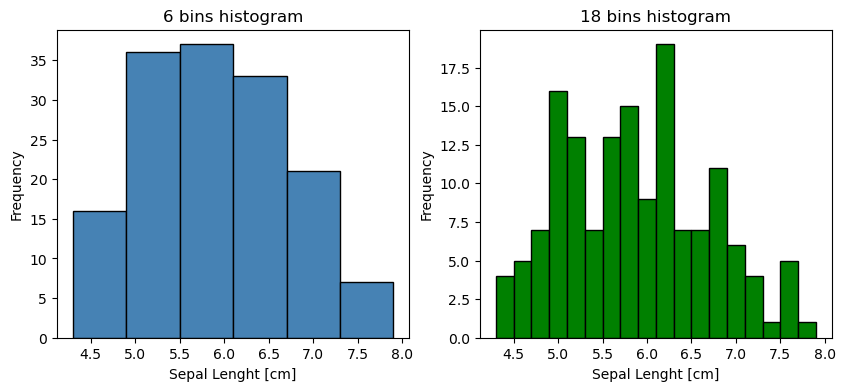

In [67]:
sepal_length = iris["sepal.length"]


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(sepal_length, bins = 6, color="steelblue", edgecolor="black")
axes[0].set_xlabel("Sepal Lenght [cm]")
axes[0].set_ylabel("Frequency")
axes[0].set_title("6 bins histogram")

axes[1].hist(sepal_length, bins = 18, color="green", edgecolor="black")
axes[1].set_xlabel("Sepal Lenght [cm]")
axes[1].set_ylabel("Frequency")
axes[1].set_title("18 bins histogram")

plt.show()

**Answer:**
1. what features of the distribution appear in both histograms

It appears that, as expected, both figures show a normal distribution, which is also one of the most common distributions observed in nature. We can clearly see that both figures have a higher count around the middle of the graph, while the sides show fewer values. Most observations are concentrated around approximately 5.0–6.5 cm, with the center around 5.8–6.0 cm. In addition, sepal lengths range from roughly 4.3 cm to 7.9 cm. The distribution also appears to have a slightly longer right tail.

2. what changes when the number of bins changes

When the number of bins increases, we get more detailed information about the distribution and the outliers. The histogram with 18 bins provides a much clearer view of how the distribution looks, especially for the lower values. With this level of detail, we can also see that some parts in the middle have lower frequencies, such as the bin around 5.25. On the other hand, the histogram with 6 bins shows the overall shape of the distribution more clearly, but the information about the values on the sides is less pronounced.

### B. Grouped numerical summary (1 pt)

Calculate the `count`, `median`, sample `std`, `min`, and `max` of `sepal.length` for each Iris species using `groupby()` and `agg()`.

Which species has the largest median `sepal.length`? Which has the largest sample standard deviation?


In [68]:
aggregate = ["count", "median", "std", "min", "max"]

iris.groupby("variety")["sepal.length"].agg(aggregate)



,count,median,std,min,max
variety,,,,,
Setosa,50,5.0,0.352490,4.3,5.8
Versicolor,50,5.9,0.516171,4.9,7.0
Virginica,50,6.5,0.635880,4.9,7.9


**Answer:**

The species with the largest median, 6.5 cm, is Virginica.

The species with the largest standard deviation, 4.9, are both Versicolor and Virginica.

### C. Boxplot by species (1.5 pts)

Create a boxplot of `sepal.length` grouped by `variety`.

Give the plot a clear title and axis labels. Then state **two conclusions** supported by the boxplot: one about differences in center and one about differences in spread or overlap among the species.


Text(0, 0.5, 'Length [cm]')

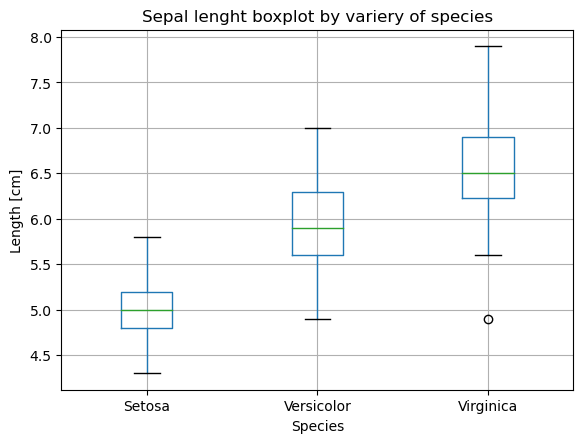

In [69]:
bp = iris.boxplot(column="sepal.length", by="variety")

plt.suptitle("")
bp.set_title("Sepal lenght boxplot by variery of species")
bp.set_xlabel("Species")
bp.set_ylabel("Length [cm]")

**Answer:**

The boxplot shows that Setosa has the lowest median sepal length at approximately 5.0 cm, followed by Versicolor at about 5.9 cm, while Virginica has the highest median at approximately 6.5 cm. This shows a clear increase in the center of the distribution across the three species.

In terms of spread, Virginica and Versicolor show greater variability than Setosa, while Setosa has the smallest spread and is relatively symmetric around its median. Virginica also has one lower outlier, around 4.9 cm, and shows the largest overall range. There is some overlap between Versicolor and Virginica, while Setosa is more separated from the other two species.

## LE2-4. Similar summaries can hide different distributions (2 pts)

The two datasets below have the same mean, median, and sample standard deviation, but their distributions are not the same.

### A. Compare numerical summaries (0.75 pt)

For datasets A and B, calculate the:
- mean;
- median; and
- sample standard deviation.

Confirm that these three numerical summaries are the same (or equal to rounding).


In [70]:
comparison = pd.DataFrame(
    {
        "A": [1, 2, 3, 4, 5, 6, 7, 8, 9],
        "B": [0, 3, 4, 5, 5, 5, 6, 7, 10],
    }
)

comparison.agg(["mean", "median", "std"]).round(2)



,A,B
mean,5.00,5.00
median,5.00,5.00
std,2.74,2.74


Yes the numerical summaries are the same.

### B. Visualize the distributions (0.75 pt)

Choose **one** of the following ways to compare datasets A and B:
- histograms using the same bins and x-axis scale; or
- boxplots shown on the same figure.

Give the visualization a clear title and meaningful axis labels.


Text(0.5, 1.0, 'Distribution B')

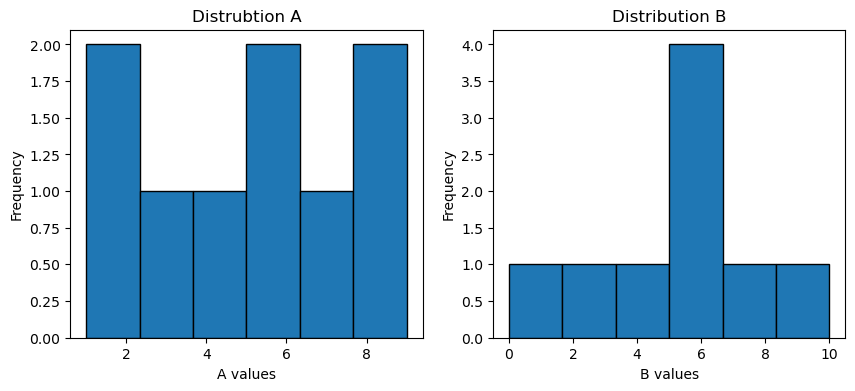

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

a = comparison["A"]
b = comparison["B"]

axes[0].hist(a, bins = 6, edgecolor ="black")
axes[0].set_xlabel("A values")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distrubtion A")

axes[1].hist(b, bins = 6, edgecolor="black")
axes[1].set_xlabel("B values")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution B")


### C. Interpret (0.5 pt)

What important difference between datasets A and B is visible in your plot but hidden by the mean, median, and sample standard deviation?

In one or two sentences, explain why numerical summaries and visualizations should be used together.

**Answer:**

The important difference is that when we plot the distributions, we can clearly see that they have significantly different shapes. Distribution A is relatively evenly spread, with values ranging from about 1 to 9 and no strong peak or long tails. Distribution B ranges from 0 to 10, but most of the values are concentrated around 5–6, with only a few observations farther away from the center. Therefore, looking only at the mean, median, and standard deviation can miss important patterns in the data that may be relevant to the analysis.

Numerical summaries and visualizations should be used together because numerical summaries provide basic information about the center and spread of the data, while visualizations show how the values are actually distributed. A visualization can reveal features such as peaks, gaps, clusters, extreme values, and the overall shape of the distribution that may not be visible from the mean, median, and standard deviation alone.

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.


{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA2",
  "export_n": 1,
  "session_date": "2026-09-12",
  "messages": [
    {"i": 1, "who": "student", "text": "check my LE2-1:\n\n| Statistic | After adding 7 | After multiplying by 3 |\n|---|---|---|\n| Mean | Mean value will move by 7 of the original x | Mean value will move by 3 times of the original x |\n| Median | Median will move by 7 like mean | Median will move 3 times similar to mean |\n| Sample standard deviation | SD will stay the same like original x | SD will increase 3 times compered to x |\n| IQR | IQR will stay the same like original x | IQR will increase 3 times |"},
    {"i": 2, "who": "tutor", "text": "Confirmed the shift/scale statistics were correct, but incorrectly claimed the table did not answer LE2-1, describing a four-pair version of the problem that is not in the student's notebook. Asked which pair they wanted to start with."},
    {"i": 3, "who": "student", "text": "[uploaded image of LE2-1: Shifting and scaling data (2 pts), x = [4, 6, 8, 10, 12], shifted = x+7, scaled = 3x, part A prediction table with student's completed answer table]"},
    {"i": 4, "who": "tutor", "text": "Corrected my own error and retracted the previous message. Confirmed all eight cells of the prediction table are correct, explained that adding a constant relocates center without changing spread while multiplying scales all four statistics. Raised whether 'move by 7' conveys direction, since the prompt asks for phrasing like 'increases by 7'."},
    {"i": 5, "who": "student", "text": "so for B i ahve created the df wiht only the data but should i put in that table or make a new table like mean std etc.\n\nx = pd.Series([4, 6, 8, 10, 12], name=\"original\")\nshifted = x + 7\nscaled = 3 * x\n\ndata = {\n    \"original\": x,\n    \"shifted\": shifted,\n    \"scaled\": scaled,\n}\n\ndf = pd.DataFrame(data)", "code": true},
    {"i": 6, "who": "tutor", "text": "Confirmed the three columns build cleanly. Explained that a raw-value frame has one row per observation while a summary table has one row per statistic, so they are different deliverables. Said I could not see part B and asked for its text."},
    {"i": 7, "who": "student", "text": "[uploaded image of B. Verify with Python (1.5 pts): summary table of mean, median, sample standard deviation, IQR, then state whether results agree with predictions; shows student's df cell and its five-row output]"},
    {"i": 8, "who": "tutor", "text": "Explained that part B needs a new table built from df. Taught frame-level .mean(), .median(), .std() returning a Series per column, noted pandas .std() defaults to ddof=1 while np.std defaults to ddof=0, taught .quantile() and index-aligned subtraction for IQR, and showed a generic dict-of-Series pd.DataFrame construction with .T for transposing."},
    {"i": 9, "who": "student", "text": "x = pd.Series([4, 6, 8, 10, 12], name=\"original\")\nshifted = x + 7\nscaled = 3 * x\n\ndata = {\n    \"name\":    [\"original\", \"shifted\", \"scaled\"],\n    \"mean\":    [x.mean(), shifted.mean(), scaled.mean()],\n    \"meidan\":  [x.median(), shifted.median(), scaled.median()],\n    \"std\":     [x.std(), shifted.std(), scaled.std()],\n    \"IQR\":     [x.quantile(0.75) - x.quantile(0.25), shifted.quantile(0.75) - shifted.quantile(0.25), scaled.quantile(0.75) - scaled.quantile(0.25)]\n}\n\ndf = pd.DataFrame(data)\n\ndf", "code": true},
    {"i": 10, "who": "tutor", "text": "Confirmed the structure gives the right summary shape and that .std() is the sample SD. Flagged the typo in the column key 'meidan'. Gave reference values: means 8, 15, 24; medians identical; sample SDs about 3.162, 3.162, 9.487; IQRs 4, 4, 12. Noted pandas quantile interpolation conventions vary across software."},
    {"i": 11, "who": "student", "text": "fixed"},
    {"i": 12, "who": "tutor", "text": "Noted the remaining piece is the sentence stating whether computed values agree with the part A predictions, and asked whether they wanted to continue or stop."},
    {"i": 13, "who": "student", "text": "i finished it now i will move to LE2-2 and see if i need something"},
    {"i": 14, "who": "tutor", "text": "Accepted, and warned about FileNotFoundError if airquality.csv is not beside the notebook — based on my incorrect expectation of what LE2-2 contained."},
    {"i": 15, "who": "student", "text": "E2-2. Quartiles, IQR, and outliers (2 pts)\nUse the Iris variable `sepal.width`.\n\n1. Calculate (Q_1), the median, and (Q_3).\n2. Calculate the IQR.\n3. Calculate the lower and upper Tukey fences: [ Q_1 - 1.5,\\mathrm{IQR} \\qquad\\text{and}\\qquad Q_3 + 1.5,\\mathrm{IQR}. ]\n4. Use Python to identify every Iris observation whose `sepal.width` falls outside these fences.\n5. Report how many observations are flagged and state whether they are low outliers, high outliers, or both.\n\n\nsepal_width = iris[\"sepal.width\"]\n\n\nq1 = sepal_width.quantile(0.25)\nq3 = sepal_width.quantile(0.75)\nmedian = sepal_width.median()\n\niqr = q3 - q1\n\nlower_fence = q1 - 1.5 * iqr\nhigher_fence = q3 + 1.5 * iqr\n\noutliers_lower = sepal_width[(sepal_width < lower_fence)]\noutliers_higher = sepal_width[(sepal_width > higher_fence)].count()\n\nprint(f\"\"\"\n1. Q1 = {q1}, median = {median}, Q3 = {q3} \\n\n2. IQR = {iqr} \\n\n3. Lower fence = {lower_fence},  Higher fence = {higher_fence}\\n\n4. low outliers = {outliers_lower}, higher outliers = {outliers_higher}\\n\"\"\")", "code": true},
    {"i": 16, "who": "student", "text": "sepal_width = iris[\"sepal.width\"]\n\n\nq1 = sepal_width.quantile(0.25)\nq3 = sepal_width.quantile(0.75)\nmedian = sepal_width.median()\n\niqr = q3 - q1\n\nlower_fence = q1 - 1.5 * iqr\nhigher_fence = q3 + 1.5 * iqr\n\noutliers_lower = sepal_width[(sepal_width < lower_fence)].count()\noutliers_higher = sepal_width[(sepal_width > higher_fence)].count()\n\nprint(f\"\"\"\n1. Q1 = {q1}, median = {median}, Q3 = {q3} \\n\n2. IQR = {iqr} \\n\n3. Lower fence = {lower_fence},  Higher fence = {higher_fence}\\n\n4. low outliers = {outliers_lower}, higher outliers = {outliers_higher}\\n\"\"\")", "code": true},
    {"i": 17, "who": "tutor", "text": "Noted both sides are now counts, which item 5 needs, but that the swap lost item 4's requirement to identify the flagged observations. Advised keeping both a masked Series and a count. Noted Series formatting inside f-strings. Gave reference values: Q1 = 2.8, median = 3.0, Q3 = 3.3, IQR = 0.5, fences 2.05 and 4.05, 1 observation below and 3 above."},
    {"i": 18, "who": "student", "text": "hiow can it be both it is either lower or higher waht do they mean by both"},
    {"i": 19, "who": "tutor", "text": "Explained that item 5 asks about the flagged set as a whole, not a single point, and laid out the three cases: low only, high only, or both ends populated. Connected each case to distribution shape and tails."},
    {"i": 20, "who": "student", "text": "i sait this : The report says that there is 1 lower outlier nad 3 higher outliers."},
    {"i": 21, "who": "tutor", "text": "Confirmed the counts match. Flagged that item 5 has two parts and the sentence never states which of the three cases applies, questioned the phrase 'the report says' since the student did the analysis, and raised whether 'higher' means the same as 'high'."},
    {"i": 22, "who": "student", "text": "okay i will move on LE2-3 and let you know"},
    {"i": 23, "who": "tutor", "text": "Accepted, and noted that since LE2-2 differed from my expectation, LE2-3 likely would too, so asked for the problem text alongside any code."},
    {"i": 24, "who": "student", "text": "[uploaded image of two sepal.length histograms, 6 bins and 18 bins, with student's written answers] A. Histograms and bin choice (1.5 pts)\nCreate two histograms of the same `sepal.length` data:\n\n* one using 6 bins;\n* one using 18 bins.\n\nGive each plot meaningful axis labels and a title. Then explain briefly:\n\n1. what features of the distribution appear in both histograms; and\n2. what changes when the number of bins changes."},
    {"i": 25, "who": "tutor", "text": "Confirmed both plots exist with titles and labels and that answer 2 captures the detail-versus-smoothness tradeoff. Challenged the 'normal distribution' claim against the student's own observed dip near 5.25 and the off-center peak, explained that pooled species produce genuine multimodality, noted that 'as expected' and 'most common in nature' say nothing about this data, and pointed out item 1 asks for features plural. Flagged 'Lenght' in both axis labels."},
    {"i": 26, "who": "student", "text": "It appears that, as expected, both figures show a normal distribution, which is also one of the most common distributions observed in nature. We can clearly see that both figures have a higher count around the middle of the graph, while the sides show fewer values. Most observations are concentrated around approximately 5.0–6.5 cm, with the center around 5.8–6.0 cm. In addition, sepal lengths range from roughly 4.3 cm to 7.9 cm. The distribution also appears to have a slightly longer right tail."},
    {"i": 27, "who": "tutor", "text": "Confirmed the added concentration range, center, span, and right tail are genuine bin-independent features matching the axes. Pointed out the normality claim now directly contradicts the student's own right-tail sentence, since normal means symmetric. Repeated that the 'common in nature' clause carries no information about the data. Noted the Tukey fence method from the previous problem could verify the tail claim on sepal.length."},
    {"i": 28, "who": "student", "text": "what does this line do:\n\niris.groupby(\"variety\")[\"sepal.length\"].agg([])", "code": true},
    {"i": 29, "who": "tutor", "text": "Explained the empty list means zero statistics requested, so the result is an empty DataFrame. Walked the chain: groupby returns a lazy GroupBy object with the grouping column becoming the output index; column selection narrows the aggregation; .agg takes a list of statistics giving one column per statistic and one row per group. Showed a generic two-statistic example, noted .mean() as a single-statistic shortcut, that 'std' is ddof=1, and that a bare string returns a Series instead of a DataFrame."},
    {"i": 30, "who": "student", "text": "Grouped numerical summary (1 pt)\nCalculate the count, median, sample std, min, and max of sepal.length for each Iris species using groupby() and agg().\n\nWhich species has the largest median sepal.length? Which has the largest sample standard deviation?\n\naggregate\naggregate = [\"count\", \"median\", \"std\", min, \"max\"]\n\niris.groupby(\"variety\")[\"sepal.length\"].agg(aggregate)\n\n\ncount\tmedian\tstd\tmin\tmax\nvariety\t\t\t\t\nSetosa\t50\t5.0\t0.352490\t4.3\t5.8\nVersicolor\t50\t5.9\t0.516171\t4.9\t7.0\nVirginica\t50\t6.5\t0.635880\t4.9\t7.9\nAnswer:\n\nThe species with the largest median, 6.5 cm, is Virginica.\n\nThe species with the largest standard deviation, 4.9, are both Versicolor and Virginica.", "code": true},
    {"i": 31, "who": "tutor", "text": "Confirmed the table matches my reference values and that the median answer is right. Identified that 4.9 comes from the min column, not std, and that two species sharing a minimum likely drew the eye there. Explained why an SD measures distance from the mean rather than magnitude, making sub-1 values the expected order. Flagged the inconsistent bare min among quoted strings."},
    {"i": 32, "who": "student", "text": "i have answers in the prompt"},
    {"i": 33, "who": "tutor", "text": "Clarified I had read them and that only the second was wrong. Stated plainly that the largest sample SD is 0.635880, belonging to Virginica, so it is a single species and not a tie, and that Virginica has both the largest median and largest spread."},
    {"i": 34, "who": "student", "text": "i create this boxplot but how i style it like to i just go iris.set_title\n\niris.boxplot(column=\"sepal.length\", by=\"variety\")", "code": true},
    {"i": 35, "who": "tutor", "text": "Explained the call returns an Axes object, which owns the title and labels, not the DataFrame. Showed capturing it and calling set_title, set_xlabel, set_ylabel. Explained that by= writes two titles on different objects, so plt.suptitle('') is needed to clear the figure-level one. Covered grid, tick_params, figsize, plt.show(), and how boxplot whiskers use the same 1.5 x IQR fences computed earlier, with fliers as flagged outliers."},
    {"i": 36, "who": "student", "text": "[uploaded image of C. Boxplot by species (1.5 pts) with completed boxplot, styling code, and two written conclusions about center and spread]"},
    {"i": 37, "who": "tutor", "text": "Confirmed both conclusions are present and supported, with medians, the 4.9 flier, largest range, overlap, and Setosa separation all read correctly. Flagged 'lenght' and 'variery' in the title and y-label, the stray Text(0, 0.5, ...) output from the echoed set_ylabel return, and the redundancy of stating the Setosa spread comparison twice, suggesting the freed space distinguish Virginica from Versicolor."},
    {"i": 38, "who": "student", "text": "so how does comaprison fucntion wokr:\n\nLE2-4. Similar summaries can hide different distributions (2 pts)\nThe two datasets below have the same mean, median, and sample standard deviation, but their distributions are not the same.\nA. Compare numerical summaries (0.75 pt)\nFor datasets A and B, calculate the:\n\n* mean;\n* median; and\n* sample standard deviation.\n\nConfirm that these three numerical summaries are the same (or equal to rounding).\n\ncomparison = pd.DataFrame(\n    {\n        \"A\": [1, 2, 3, 4, 5, 6, 7, 8, 9],\n        \"B\": [0, 3, 4, 5, 5, 5, 6, 7, 10],\n    }\n)\n\ncomparison\n\n# Useful pattern:\n# comparison.agg([\"mean\", \"median\", \"std\"])\n\n# Your code here", "code": true},
    {"i": 39, "who": "tutor", "text": "Clarified comparison is a variable name, not a function, and that .agg is the same method seen earlier but called on a DataFrame rather than a GroupBy. Showed on toy data that statistics become row labels while original columns stay columns, explained column-wise application, ddof=1 for 'std', .T, and .round(2) for the 'equal to rounding' wording. Gave reference values: both datasets have mean 5, median 5, sample SD about 2.739."},
    {"i": 40, "who": "student", "text": "[uploaded image of two histograms titled Distrubtion A and Distribution B on different axis scales, plus C. Interpret answer claiming A is missing a middle value that splits it into two groups] C. Interpret (0.5 pt)\nWhat important difference between datasets A and B is visible in your plot but hidden by the mean, median, and sample standard deviation?\nIn one or two sentences, explain why numerical summaries and visualizations should be used together.isualize the distributions (0.75 pt)\nChoose one of the following ways to compare datasets A and B:\n\n* histograms using the same bins and x-axis scale; or\n* boxplots shown on the same figure.\n\nGive the visualization a clear title and meaningful axis l"},
    {"i": 41, "who": "tutor", "text": "Praised the second paragraph's summary-versus-visualization structure. Demonstrated by computing histogram counts that dataset A is the complete integers 1 through 9 and the apparent gap is a bin-width artifact, since 0.8-wide bins leave the interval containing 5 empty. Noted the irony that visualizations can manufacture structure. Flagged that the plots violate the stated same-bins, same-x-scale requirement, with mismatched bin widths and y-ranges. Flagged 'Distrubtion A'."},
    {"i": 42, "who": "student", "text": "[uploaded image of revised histograms, A in five bins spanning 1-9 and B in six bins spanning 0-10, with a heavily typo-laden C answer] i"},
    {"i": 43, "who": "tutor", "text": "Noted the bin edges still do not align and the y-limits still differ, so a bar position does not mean the same interval in both plots. Identified that the student had A and B swapped: A contains every integer 1 through 9 while B is missing 1, 2, 8, and 9. Framed the real contrast as flat versus peaked with isolated edge points, both yielding mean 5, median 5, SD about 2.739. Noted the paragraph's typos make it unreadable for a grader."},
    {"i": 44, "who": "student", "text": "okay i fixed it it"},
    {"i": 45, "who": "tutor", "text": "Accepted, noted the A/B orientation was the substantive fix, and asked whether to continue or wrap up."},
    {"i": 46, "who": "student", "text": "make my record"}
  ],
  "events": [
    {"i": 1, "part": "2-1", "type": "code"},
    {"i": 5, "part": "2-1", "type": "code"},
    {"i": 9, "part": "2-1", "type": "code"},
    {"i": 13, "part": "2-1", "type": "part_pass"},
    {"i": 15, "part": "2-2", "type": "code"},
    {"i": 16, "part": "2-2", "type": "code"},
    {"i": 18, "part": "2-2", "type": "explain"},
    {"i": 22, "part": "2-2", "type": "part_pass"},
    {"i": 28, "part": "2-3", "type": "explain"},
    {"i": 30, "part": "2-3", "type": "code"},
    {"i": 34, "part": "2-3", "type": "explain"},
    {"i": 38, "part": "2-4", "type": "explain"},
    {"i": 42, "part": "2-4", "type": "code"},
    {"i": 44, "part": "2-4", "type": "part_pass"}
  ],
  "parts": [
    {"part": "2-1", "exchanges": 5, "max_tier": 2, "passed": true},
    {"part": "2-2", "exchanges": 4, "max_tier": 3, "passed": true},
    {"part": "2-3", "exchanges": 5, "max_tier": 3, "passed": true},
    {"part": "2-4", "exchanges": 4, "max_tier": 3, "passed": true}
  ],
  "tutor_assessment": [
    "The longest stall was on LE2-4C, where the student twice described dataset A as having a gap that split it into two groups. The first version was a real binning artifact, which is a genuinely subtle trap; the second persisted after the artifact was explained and turned out to be a straight A/B swap, since B is the dataset with missing values. Underneath that sat an unmet stated requirement: across two attempts the histograms never used aligned bin edges or matched axis limits, which is exactly what makes a side-by-side comparison readable. A recurring pattern across the whole session was reading the right number from the wrong column or object: 4.9 pulled from min instead of std in the grouped summary, and counts substituted for the flagged observations themselves in the Tukey problem. Interpretive prose was also a consistent weak point, with the LE2-3A normality claim contradicting the student's own right-tail observation and several answers addressing only one of two printed sub-questions.",
    "No release-valve use and no unstuck declarations occurred, so neither reflects on the tutoring. The tutoring itself failed at the start: I served a four-pair version of LE2-1 that does not exist in this student's notebook, told them their correct table did not answer the problem, and asked them to start over on pairs a through d. That cost a full exchange and could have led them to discard correct work. I repeated the same error at message 14 by warning about airquality.csv. The project's canonical blocks describe a different Weekly Assignment 2 than the notebook this student is working from; the student never received a served block, which prevented further damage, but the mismatch should be resolved before another student hits it. Also note the student's message at 32 was a reasonable complaint that my feedback looked like it had ignored answers already given, which suggests my correction at 31 buried the actual point."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.
